# 2022-09-01_koseki_a_efp.dat & 2022-09-01_koseki_a_fgh.dat

21-Jul-25 17:49:41: del_data: No valid tplot variables found, returning
21-Jul-25 17:49:41: /tmp/ipykernel_4416/3509751672.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_E_1 = pd.read_csv(

21-Jul-25 17:49:43: /tmp/ipykernel_4416/3509751672.py:21: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_E_2 = pd.read_csv(

21-Jul-25 17:49:44: /tmp/ipykernel_4416/3509751672.py:29: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_B_1 = pd.read_csv(

21-Jul-25 17:49:44: /tmp/ipykernel_4416/3509751672.py:35: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_B_2 = pd.read_csv(



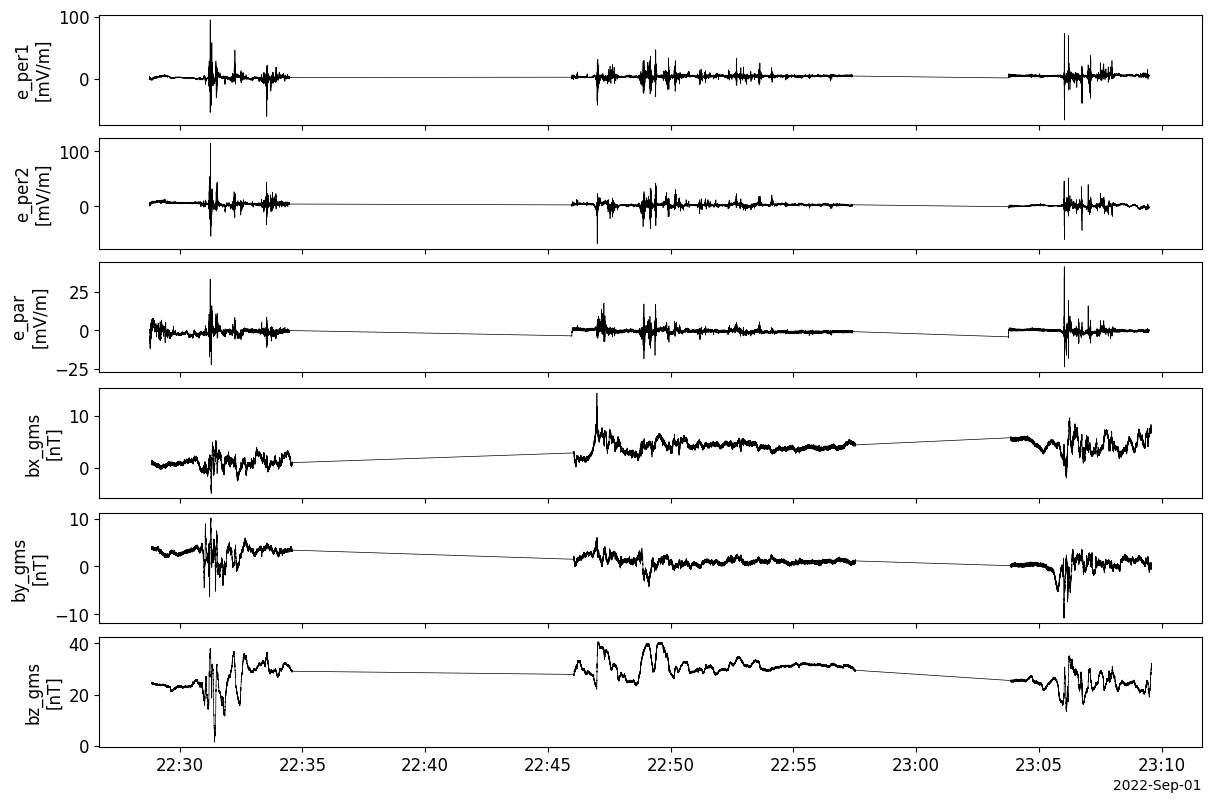

In [1]:
import pandas as pd
import numpy as np
import pytplot as pt
import xarray as xr

pt.del_data('*')

dir_name = f'/mnt/j/observation_data/THEMIS_A_from_Artemyev'

file_name_E_1 = f'{dir_name}/2022-09-01_koseki_a_efp_22-23.dat'
file_name_E_2 = f'{dir_name}/2022-09-01_koseki_a_efp_23-24.dat'
file_name_B_1 = f'{dir_name}/2022-09-01_koseki_a_fgh_22-23.dat'
file_name_B_2 = f'{dir_name}/2022-09-01_koseki_a_fgh_23-24.dat'

df_E_1 = pd.read_csv(
    file_name_E_1,
    delim_whitespace=True,
    parse_dates=['time']
)

df_E_2 = pd.read_csv(
    file_name_E_2,
    delim_whitespace=True,
    parse_dates=['time']
)

df_E = pd.concat([df_E_1, df_E_2], ignore_index=True)

df_B_1 = pd.read_csv(
    file_name_B_1,
    delim_whitespace=True,
    parse_dates=['time']
)

df_B_2 = pd.read_csv(
    file_name_B_2,
    delim_whitespace=True,
    parse_dates=['time']
)

df_B = pd.concat([df_B_1, df_B_2], ignore_index=True)

time_E = df_E['time'].to_numpy(dtype='datetime64[ns]')
time_B = df_B['time'].to_numpy(dtype='datetime64[ns]')

for col in ['e_per1', 'e_per2', 'e_par']:
    pt.store_data(
        col,
        data={'x': time_E, 'y': df_E[col].to_numpy()}   # FAC
    )
    pt.options(col, 'ytitle', col)
    pt.options(col, 'ysubtitle', '[mV/m]')

for col in ['bx_gms', 'by_gms', 'bz_gms']:
    pt.store_data(
        col,
        data={'x': time_B, 'y': df_B[col].to_numpy()}   # GMS
    )
    pt.options(col, 'ytitle', col)
    pt.options(col, 'ysubtitle', '[nT]')

# -------------------------------
# 3. プロット
# -------------------------------
pt.tplot(['e_per1', 'e_per2', 'e_par', 'bx_gms', 'by_gms', 'bz_gms'])

In [ ]:
import numpy as np
import pytplot as pt
gap_thr = np.timedelta64(10, 's')

# ---------- 1. 電場チャンク ----------------------------------
t_ref_E = pt.data_quants['e_per1'].time.values
is_new_E = np.concatenate(([True], np.diff(t_ref_E) > gap_thr))
chunk_E  = np.cumsum(is_new_E) - 1

# ---------- 2. 磁場チャンク ----------------------------------
t_ref_B = pt.data_quants['bx_gms'].time.values
is_new_B = np.concatenate(([True], np.diff(t_ref_B) > gap_thr))
chunk_B  = np.cumsum(is_new_B) - 1

# ---------- 3. 分割ループ ------------------------------------
vars_E = ['e_per1','e_per2','e_par']
vars_B = ['bx_gms','by_gms','bz_gms']

def split_and_store(var_list, t_ref, chunk_id):
    for v in var_list:
        da   = pt.data_quants[v]
        for k in np.unique(chunk_id):
            sel = chunk_id == k
            if sel.sum() == 0:
                continue
            new = f'{v}_seg{k}'
            pt.store_data(new,
                          data={'x': t_ref[sel], 'y': da.values[sel]})
            unit = '[mV/m]' if v.startswith('e_') else '[nT]'
            pt.options(new,'ytitle',v); pt.options(new,'ysubtitle',unit)

split_and_store(vars_E, t_ref_E, chunk_E)
split_and_store(vars_B, t_ref_B, chunk_B)

# ---------- 4. まとめ変数 ------------------------------------
def make_all(base):
    pt.store_data(f'{base}_all', data=pt.tnames(f'{base}_seg*'))

for base in vars_E + vars_B:
    make_all(base)

# ---------- 5. 描画 ------------------------------------------
pt.tplot(['e_per1_all','e_per2_all','e_par_all',
          'bx_gms_all','by_gms_all','bz_gms_all'])


In [ ]:
import numpy as np
import xarray as xr
import pytplot as pt

# ────────────────────────────────────────────────
# 0. セグメント名リストを取得
# ────────────────────────────────────────────────
seg_ids = sorted({v.split('_seg')[-1]                      # {'0','1',...}
                  for v in pt.tnames('e_per1_seg*')})

# まとめ用リスト（後で overplot するために使う）
e1_all, e2_all, ep_all = [], [], []
bx_all, by_all, bz_all = [], [], []

# ────────────────────────────────────────────────
# 1. 各セグメントごとに処理
# ────────────────────────────────────────────────
for sid in seg_ids:
    # TVar 取り出し → pandas DataFrame へ （xarray に変換するため）
    def to_df(var):           # var = 'e_per1_seg0' など
        dq = pt.data_quants[var]
        return pd.DataFrame({'time': dq.time.values,
                             var.split('_seg')[0]: dq.values})

    df_E = (to_df(f'e_per1_seg{sid}')
            .merge(to_df(f'e_per2_seg{sid}'), on='time')
            .merge(to_df(f'e_par_seg{sid}'),  on='time'))

    df_B = (to_df(f'bx_gms_seg{sid}')
            .merge(to_df(f'by_gms_seg{sid}'), on='time')
            .merge(to_df(f'bz_gms_seg{sid}'), on='time'))

    # ---- xarray Dataset へ ----
    ds_E = xr.Dataset({k:(('time',), df_E[k].to_numpy(dtype=float))
                       for k in ['e_per1','e_per2','e_par']},
                      coords={'time': df_E['time'].to_numpy('datetime64[ns]')})

    ds_B = xr.Dataset({k:(('time',), df_B[k].to_numpy(dtype=float))
                       for k in ['bx_gms','by_gms','bz_gms']},
                      coords={'time': df_B['time'].to_numpy('datetime64[ns]')})

    # ---- B を E の時刻へ線形補間 ----
    ds_B_i  = ds_B.interp(time=ds_E.time, method='linear')
    ds_merged = xr.merge([ds_E, ds_B_i])

    # ---- TVar 登録（seg ID を引き継ぐ） ----
    for var in ds_merged.data_vars:
        new_name = f'{var}_seg{sid}_i'          # 例: e_per1_seg0_i
        pt.store_data(new_name,
                      data={'x': ds_merged.time.values,
                            'y': ds_merged[var].values})
        unit = '[mV/m]' if var.startswith('e_') else '[nT]'
        pt.options(new_name, 'ytitle', var)
        pt.options(new_name, 'ysubtitle', unit)

        # まとめリストへ追加
        if   var == 'e_per1': e1_all.append(new_name)
        elif var == 'e_per2': e2_all.append(new_name)
        elif var == 'e_par' : ep_all.append(new_name)
        elif var == 'bx_gms': bx_all.append(new_name)
        elif var == 'by_gms': by_all.append(new_name)
        elif var == 'bz_gms': bz_all.append(new_name)

# ────────────────────────────────────────────────
# 2. overplot 用の “まとめ変数” を 6 つ作成
# ────────────────────────────────────────────────
pt.store_data('e_per1_all_i', data=e1_all)
pt.store_data('e_per2_all_i', data=e2_all)
pt.store_data('e_par_all_i',  data=ep_all)
pt.store_data('bx_gms_all_i', data=bx_all)
pt.store_data('by_gms_all_i', data=by_all)
pt.store_data('bz_gms_all_i', data=bz_all)

# ────────────────────────────────────────────────
# 3. プロット（6 パネル、各パネルに全セグメントが重なって表示）
# ────────────────────────────────────────────────
pt.tplot(['e_per1_all_i','e_per2_all_i','e_par_all_i',
          'bx_gms_all_i','by_gms_all_i','bz_gms_all_i'])


In [ ]:
import pandas as pd
import pytplot as pt
import xarray as xr
import numpy as np

file_name_fgm_1 = f'{dir_name}/2022-09-01_koseki_tha_fgm_22-23.dat'
file_name_fgm_2 = f'{dir_name}/2022-09-01_koseki_tha_fgm_23-24.dat'

df_fgm_1 = pd.read_csv(
    file_name_fgm_1,
    delim_whitespace=True,
    parse_dates=['time']
)

df_fgm_2 = pd.read_csv(
    file_name_fgm_2,
    delim_whitespace=True,
    parse_dates=['time']
)

df_fgm = pd.concat([df_fgm_1, df_fgm_2], ignore_index=True)

df_fgm_gms = df_fgm[['time', 'bx_gms', 'by_gms', 'bz_gms']].copy()
df_fgm_gms['time'] = df_fgm_gms['time'].astype('datetime64[ns]')

ds_fgm_gms = xr.Dataset({
    'bx_gms': ('time', df_fgm_gms['bx_gms'].to_numpy(dtype=float)),
    'by_gms': ('time', df_fgm_gms['by_gms'].to_numpy(dtype=float)),
    'bz_gms': ('time', df_fgm_gms['bz_gms'].to_numpy(dtype=float))
}, coords={'time': df_fgm_gms['time'].to_numpy('datetime64[ns]')})

ds_fgm_gms

In [ ]:
import numpy as np
import xarray as xr
import pytplot as pt

def gms_to_fac(ds_hf: xr.Dataset, ds_lf: xr.Dataset,
               window_sec=100.0) -> tuple[xr.Dataset, xr.DataArray]:
    # ---------- 1. <B> の移動平均 (低周波) ---------------------------
    t_lf   = ds_lf.time.values
    dt     = (t_lf[1]-t_lf[0]).astype('timedelta64[ns]').astype(float)*1e-9
    win    = int(window_sec/dt)

    B_lf   = np.stack([ds_lf[k].values for k in ['bx_gms','by_gms','bz_gms']], axis=1)
    B_avg  = np.vstack([np.nanmean(B_lf[max(i-win//2,0):i+win//2+1], axis=0)
                        for i in range(len(B_lf))])        # (N_lf,3)

    # ---------- 2. FAC 基底 (NumPy) ---------------------------------
    z0 = np.array([0.,0.,1.])
    e2 = np.cross(z0, B_avg)            # (N,3)
    e1 = np.cross(e2, B_avg)
    def _norm(v): return v / np.linalg.norm(v, axis=1, keepdims=True)
    e1h, e2h, e3h = map(_norm, (e1,e2,B_avg))

    R_np = np.stack([e1h, e2h, e3h], axis=2)   # (N_lf,3,3)

    # ---------- 3. DataArray 化して高周波へ補間 -----------------------
    R_da = xr.DataArray(R_np, dims=('time','row','col'),
                        coords={'time': t_lf, 'row':[0,1,2], 'col':[0,1,2]})
    R_hf = R_da.interp(time=ds_hf.time)         # (N_hf,3,3)

    # ---------- 4. B を回して FAC へ --------------------------------
    B_gms_hf = np.stack([ds_hf[k].values for k in ['bx_gms','by_gms','bz_gms']], axis=1)
    B_fac_np = np.einsum('tij,tj->ti', R_hf.values, B_gms_hf)  # (N_hf,3)

    # ---------- 5. Dataset に格納 -----------------------------------
    ds_out = xr.Dataset(
        data_vars=dict(
            Ex_fac = (('time'), ds_hf['e_per1'].values),
            Ey_fac = (('time'), ds_hf['e_per2'].values),
            Ez_fac = (('time'), ds_hf['e_par' ].values),
            Bx_fac = (('time'), B_fac_np[:,0]),
            By_fac = (('time'), B_fac_np[:,1]),
            Bz_fac = (('time'), B_fac_np[:,2]),
        ),
        coords=dict(time=ds_hf.time)
    )
    return ds_out, R_hf

# ------------------------------------------------------------
# 0. seg ID を列挙（e_per1_seg* がすでに存在している想定）
# ------------------------------------------------------------
seg_ids = sorted({n.split('_seg')[1].split('_')[0] for n in pt.tnames('e_per1_seg*_i')})

# FAC 変換後の TVar をまとめておくリスト
Ex_all, Ey_all, Ez_all = [], [], []
Bx_all, By_all, Bz_all = [], [], []

R_dict = {}

# ------------------------------------------------------------
# 1. segment ごとに DSI→FAC 変換
# ------------------------------------------------------------
for sid in seg_ids:
    # ------- E と B の DataFrame 取得 -------
    def to_df(var):
        dq = pt.data_quants[f'{var}_seg{sid}']
        base = var.split('_seg')[0]           # e_per1 等
        return pd.DataFrame({'time': dq.time.values,
                             base: dq.values})

    df_E = (to_df('e_per1')
            .merge(to_df('e_per2'), on='time')
            .merge(to_df('e_par'),  on='time'))
    df_B = (to_df('bx_gms')
            .merge(to_df('by_gms'), on='time')
            .merge(to_df('bz_gms'), on='time'))

    # ------- xarray Dataset に変換 -------
    ds_E = xr.Dataset({k:(('time',), df_E[k]) for k in ['e_per1','e_per2','e_par']},
                      coords={'time': df_E['time'].to_numpy('datetime64[ns]')})
    ds_B = xr.Dataset({k:(('time',), df_B[k]) for k in ['bx_gms','by_gms','bz_gms']},
                      coords={'time': df_B['time'].to_numpy('datetime64[ns]')})

    # ------- B を E 時刻へ線形補間してマージ -------
    ds_merged = xr.merge([ds_E, ds_B.interp(time=ds_E.time, method='linear')])

    # ------- FAC 変換 -------
    ds_fac, Rotational_tensor = gms_to_fac(ds_merged, ds_fgm_gms, window_sec=100.0)

    R_dict[f'R_seg{sid}'] = {
        'R':   Rotational_tensor,          # (N,3,3) np.ndarray
        'time': ds_fac.time.values         # (N,)   datetime64[ns]
    }

    # ------- tplot へ登録 (seg ID を残す) -------
    for v in ['Ex_fac','Ey_fac','Ez_fac','Bx_fac','By_fac','Bz_fac']:
        new = f'{v}_seg{sid}'
        pt.store_data(new, data={'x': ds_fac.time.values, 'y': ds_fac[v].values})
        unit = '[mV/m]' if v.startswith('E') else '[nT]'
        pt.options(new, 'ytitle', v)
        pt.options(new, 'ysubtitle', unit)

        # 後で overplot 用にリストへ
        if   v == 'Ex_fac': Ex_all.append(new)
        elif v == 'Ey_fac': Ey_all.append(new)
        elif v == 'Ez_fac': Ez_all.append(new)
        elif v == 'Bx_fac': Bx_all.append(new)
        elif v == 'By_fac': By_all.append(new)
        elif v == 'Bz_fac': Bz_all.append(new)

# ------------------------------------------------------------
# 2. まとめ変数を作って overplot
# ------------------------------------------------------------
pt.store_data('Ex_fac_all', data=Ex_all)
pt.store_data('Ey_fac_all', data=Ey_all)
pt.store_data('Ez_fac_all', data=Ez_all)
pt.store_data('Bx_fac_all', data=Bx_all)
pt.store_data('By_fac_all', data=By_all)
pt.store_data('Bz_fac_all', data=Bz_all)

# 6 パネル表示（上 3＝E、下 3＝B）
pt.tplot(['Ex_fac_all','Ey_fac_all','Ez_fac_all',
          'Bx_fac_all','By_fac_all','Bz_fac_all'])


In [ ]:
R_dict

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- R と時刻を連結 -------------------------------------------------
R_all   = np.concatenate([R_dict[f'R_seg{sid}']['R']    for sid in seg_ids])
time_all = np.concatenate([R_dict[f'R_seg{sid}']['time'] for sid in seg_ids])

# --- 角度 θ(t) ------------------------------------------------------
e3_z = R_all[:, 2, 2]                       # ẑ·ê₃
angle_deg = np.degrees(
    np.arccos(np.clip(e3_z, -1.0, 1.0))     # 丸め誤差で±1を超えないように
)

# --- プロット -------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(time_all, angle_deg, lw=1)          # ← time_all を使う
ax.set_ylabel(r'∠($\mathbf{B}_0$, $\hat z_{\mathrm{GMS}}$) [deg]')
ax.set_xlabel('Time')
ax.set_title('Rotation angle between $\\mathbf{B}_0$ and GMS $z$‑axis')
ax.grid(True)
fig.autofmt_xdate()                         # 日付ラベルを自動整形
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt, sosfreqz

# ------------------ フィルタ設計 ------------------
fs = 512               # サンプリング周波数 [Hz]
cutoff = 0.45            # カットオフ周波数 [Hz]  (spin=8 s → 0.125 Hz より少し高め)
order = 4               # 4次 Butterworth（2-pole × 2-stage）
spin_tone = 1/3         # spin周期 (ERG: 8 sec, THEMIS: 3 sec)

sos = butter(N=order, Wn=cutoff/(fs/2), btype='high', output='sos')

# ------------------ インパルス応答 ------------------
n = 2048                            # インパルス長さ（padlen より十分長く）
delta = np.zeros(n)
delta[n//2] = 1                    # 中央に δ(0)

h = sosfiltfilt(sos, delta)         # 0 相フィルタとして通す
t = (np.arange(n) - n//2) / fs      # 時間軸（0 を中心にシフト）

# ------------------ 周波数応答（片方向１回分） ------------------
w, H = sosfreqz(sos, worN=4096, fs=fs)   # |H(f)| 片方向

# filtfilt は 2 回かけるので、実際の振幅応答は |H(f)|^2 になる
H_dbl = np.abs(H)**2

# ------------------ プロット ------------------
fig, axs = plt.subplots(2, 1, figsize=(10, 6), tight_layout=True)

# 時間領域
axs[0].plot(t, h)
axs[0].set_title('Impulse response (zero-phase, 8-pole equivalent)')
axs[0].set_xlabel('Time [s]')
axs[0].set_ylabel('Amplitude')
axs[0].grid(True)

# 周波数領域
axs[1].semilogx(w, 20*np.log10(H_dbl), label='|H(f)| (double-pass)')
axs[1].axvline(cutoff, color='grey', ls='--', label=f'cutoff = {cutoff:.3f} Hz')
axs[1].axvline(spin_tone, color='green', ls='--', label=f'spin tone = {spin_tone:.3f} Hz')
axs[1].set_title('Magnitude response (double-pass, filtfilt)')
axs[1].set_xlabel('Frequency [Hz]')
axs[1].set_ylabel('Magnitude [dB]')
axs[1].set_ylim(-20)
axs[1].set_xlim(4E-2)
#axs[1].set_yscale('symlog', linthresh=1E-1)
axs[1].legend()
axs[1].grid(True, which='both', ls='--')

plt.show()

In [ ]:
# ------------------------------------------------------------
# 0. Butterworth HPF の係数（質問文と同じ）
# ------------------------------------------------------------
import numpy as np
from scipy.signal import butter, sosfiltfilt
import pytplot as pt

fs, cutoff = 512.0, 0.45
sos = butter(4, cutoff/(fs/2), btype='high', output='sos')

def hp_segmented(y, sos_mat):
    """NaN を含む 1‑D 配列にセグメントごとで sosfiltfilt"""
    good = np.isfinite(y)
    out  = np.full_like(y, np.nan)
    idx  = np.where(good)[0]
    segs = np.split(idx, np.where(np.diff(idx) != 1)[0] + 1)
    padlen = 3 * (sos_mat.shape[0]-1)
    for s in segs:
        if s.size > padlen:
            out[s] = sosfiltfilt(sos_mat, y[s])
    return out

# ------------------------------------------------------------
# 1. セグメント ID を列挙
# ------------------------------------------------------------
seg_ids = sorted({v.split('_seg')[-1] for v in pt.tnames('Ex_fac_seg*')})

# overplot まとめ変数用
Ex_hp, Ey_hp, Ez_hp = [], [], []
Bx_hp, By_hp, Bz_hp = [], [], []

# ------------------------------------------------------------
# 2. 各 seg で HPF → TVar 登録
# ------------------------------------------------------------
for sid in seg_ids:
    for base in ['Ex_fac', 'Ey_fac', 'Ez_fac', 'Bx_fac', 'By_fac', 'Bz_fac']:
        src = f'{base}_seg{sid}'
        da  = pt.data_quants[src]
        hp  = hp_segmented(da.values, sos)

        dst = f'{base}_seg{sid}_hp'
        pt.store_data(dst, data={'x': da.time.values, 'y': hp})

        # 保存しておいて後で overplot 用リストへ
        if   base == 'Ex_fac': Ex_hp.append(dst)
        elif base == 'Ey_fac': Ey_hp.append(dst)
        elif base == 'Ez_fac': Ez_hp.append(dst)
        elif base == 'Bx_fac': Bx_hp.append(dst)
        elif base == 'By_fac': By_hp.append(dst)
        elif base == 'Bz_fac': Bz_hp.append(dst)

        unit = '[mV/m]' if base.startswith('E') else '[nT]'
        pt.options(dst, 'ytitle', base.replace('_fac',' HP'))
        pt.options(dst, 'ysubtitle', unit)

# ------------------------------------------------------------
# 3. まとめ変数を作って overplot
# ------------------------------------------------------------
pt.store_data('Ex_fac_hp_all', data=Ex_hp)
pt.store_data('Ey_fac_hp_all', data=Ey_hp)
pt.store_data('Ez_fac_hp_all', data=Ez_hp)
pt.store_data('Bx_fac_hp_all', data=Bx_hp)
pt.store_data('By_fac_hp_all', data=By_hp)
pt.store_data('Bz_fac_hp_all', data=Bz_hp)

# ------------------------------------------------------------
# 4. 描画（6 パネル）
# ------------------------------------------------------------
pt.tplot(['Ex_fac_hp_all', 'Ey_fac_hp_all', 'Ez_fac_hp_all',
          'Bx_fac_hp_all', 'By_fac_hp_all', 'Bz_fac_hp_all'])


In [ ]:
import numpy as np
import pyspedas as psp          # tdpwrspc を呼ぶ
import pytplot as pt

# FFT パラメータ
nbox, nshift = 4096, 4096//8    # ≈8 秒窓を 1 秒刻みでズラすイメージ
bin_size     = 1                # 周波数ビン幅

# まとめ用リスト
Ex_psd, Ey_psd, Ez_psd = [], [], []
Bx_psd, By_psd, Bz_psd = [], [], []

# ── 各セグメントについて処理 ─────────────────────
seg_ids = sorted({v.split('_seg')[-1] for v in pt.tnames('Ex_fac_seg*')})

for sid in seg_ids:
    for EB, unit in [('E', r'(mV/m)$^{2}$/Hz'), ('B', r'nT$^{2}$/Hz')]:
        for comp in ['x', 'y', 'z']:
            src = f'{EB}{comp}_fac_seg{sid}_hp'           # high‑pass 済み
            if src not in pt.data_quants:
                continue

            # PSD 生成（dpwrspc） --------------
            psp.tdpwrspc(src, nboxpoints=nbox,
                              nshiftpoints=nshift,
                              bin=bin_size)               # → src_dpwrspc

            dst = f'{src}_dpwrspc'
            # 軸ラベルなど
            pt.options(dst, 'ylog', 1)
            pt.options(dst, 'zlog', 1)
            pt.options(dst, 'colormap', 'turbo')
            pt.options(dst, 'ztitle', unit)
            pt.options(dst, 'ytitle', f'{EB}_{comp.upper()} PSD')
            pt.options(dst, 'zrange', [1e-2, 1e2])

            # まとめリストに追加
            if   EB == 'E' and comp == 'x': Ex_psd.append(dst)
            elif EB == 'E' and comp == 'y': Ey_psd.append(dst)
            elif EB == 'E' and comp == 'z': Ez_psd.append(dst)
            elif EB == 'B' and comp == 'x': Bx_psd.append(dst)
            elif EB == 'B' and comp == 'y': By_psd.append(dst)
            elif EB == 'B' and comp == 'z': Bz_psd.append(dst)



# ── over‑plot 用リンク変数を作成 ─────────────────
pt.store_data('Ex_psd_all', data=Ex_psd)
pt.store_data('Ey_psd_all', data=Ey_psd)
pt.store_data('Ez_psd_all', data=Ez_psd)
pt.store_data('Bx_psd_all', data=Bx_psd)
pt.store_data('By_psd_all', data=By_psd)
pt.store_data('Bz_psd_all', data=Bz_psd)

for var in ['Ex_psd_all', 'Ey_psd_all', 'Ez_psd_all',
                  'Bx_psd_all', 'By_psd_all', 'Bz_psd_all']:
    pt.options(var, 'ylog', 1)
    pt.options(var, 'zlog', 1)
    pt.options(var, 'colormap', 'turbo')
    pt.options(var, 'ztitle', r'(mV/m)$^{2}$/Hz' if var.startswith('E') else r'nT$^{2}$/Hz')
    pt.options(var, 'zrange', [1e-2, 1e2])  # z軸の範囲を統一

# ── 描画：6 パネルで PSD を一望 ─────────────────
pt.tplot(['Ex_psd_all', 'Ey_psd_all', 'Ez_psd_all',
          'Bx_psd_all', 'By_psd_all', 'Bz_psd_all'])

In [ ]:
import pandas as pd
import pytplot as pt

file_name_electron_1 = f'{dir_name}/2022-09-01_koseki_a_mom_e_22-23.dat'
file_name_electron_2 = f'{dir_name}/2022-09-01_koseki_a_mom_e_23-24.dat'

df_electron_1 = pd.read_csv(
    file_name_electron_1,
    delim_whitespace=True,
    parse_dates=['time']
)

df_electron_2 = pd.read_csv(
    file_name_electron_2,
    delim_whitespace=True,
    parse_dates=['time']
)

df_electron = pd.concat([df_electron_1, df_electron_2], ignore_index=True)

pt.store_data(
    'electron_density',
    data={'x': df_electron['time'].values, 'y': df_electron['density[cm-3]'].values}
)
pt.options('electron_density', 'ysubtitle', r'$[\mathrm{m}^{-3}]$')

pt.tplot('electron_density')

In [ ]:
import pandas as pd
import pytplot as pt
import xarray as xr
import numpy as np

file_name_fgm_1 = f'{dir_name}/2022-09-01_koseki_tha_fgm_22-23.dat'
file_name_fgm_2 = f'{dir_name}/2022-09-01_koseki_tha_fgm_23-24.dat'

df_fgm_1 = pd.read_csv(
    file_name_fgm_1,
    delim_whitespace=True,
    parse_dates=['time']
)

df_fgm_2 = pd.read_csv(
    file_name_fgm_2,
    delim_whitespace=True,
    parse_dates=['time']
)

df_fgm = pd.concat([df_fgm_1, df_fgm_2], ignore_index=True)

df_fgm_gms = df_fgm[['time', 'bx_gms', 'by_gms', 'bz_gms']].copy()
df_fgm_total = xr.Dataset({
    'b_total':
    np.sqrt(df_fgm_gms['bx_gms']**2 +
              df_fgm_gms['by_gms']**2 +
              df_fgm_gms['bz_gms']**2)
    },
    coords={'time': df_fgm_gms['time'].values}
)

pt.store_data(
    'fgm_total',
    data={'x': df_fgm_total['time'].values, 'y': df_fgm_total['b_total'].values}
)
pt.options('fgm_total', 'ytitle', 'fgm_total')
pt.options('fgm_total', 'ysubtitle', '[nT]')
pt.tplot('fgm_total')

In [ ]:
import numpy as np, pytplot as pt, xarray as xr

fgm_total = pt.data_quants['fgm_total']
density = pt.data_quants['electron_density']

density_time = pt.data_quants['electron_density'].time.values

dt_ns = np.median(np.diff(density_time).astype('timedelta64[ns]').astype(float))
dt_sec = dt_ns * 1e-9

fgm_total_interp = fgm_total.interp(time=density_time, method='linear')

mu0 = 4*np.pi*1e-7
mp  = 1.6726219e-27
n_i = density.values * 1e6           # cm⁻³ → m⁻³

v_A = fgm_total_interp * 1e-9 / np.sqrt(mu0 * mp * n_i)  # [m/s]

pt.store_data('Alfven_speed',
              data={'x': density_time, 'y': v_A})
pt.options('Alfven_speed', 'ytitle', 'Alfvén speed')
pt.options('Alfven_speed', 'ysubtitle', '[m/s]')
pt.tplot('Alfven_speed')

In [ ]:
import numpy as np
import pytplot as pt

# ------------------------------------------------------------
# 1. 対象セグメント ID を列挙（手動 or 自動）
# ------------------------------------------------------------
seg_ids = ['0', '1', '2']                 # ここを増減しても OK

# Alfvén 速度 元データ
v_A = pt.data_quants['Alfven_speed']      # xarray.DataArray

vA_vars = []                              # まとめ用リスト

# ------------------------------------------------------------
# 2. 各セグメントで補間 → TVar 登録
# ------------------------------------------------------------
for sid in seg_ids:
    psd_var = f'Bx_fac_seg{sid}_hp_dpwrspc'
    if psd_var not in pt.data_quants:
        print(f'skip (no {psd_var})')
        continue

    psd_da = pt.data_quants[psd_var]      # PSD DataArray
    t_psd  = psd_da.time.values           # 1‑D datetime64[ns]

    # 線形補間
    vA_interp = v_A.interp(time=t_psd, method='linear')

    # tplot 変数名
    new = f'vA_seg{sid}_interp'
    vA_vars.append(new)

    pt.store_data(new,
                  data={'x': t_psd,
                        'y': vA_interp.values})

    pt.options(new, 'ytitle', 'Alfvén speed')
    pt.options(new, 'ysubtitle', '[m/s]')
    # 目立たせたい場合は色指定など
    # pt.options(new, 'color', [idx, 0, 255-idx*30])

# ------------------------------------------------------------
# 3. まとめ変数で over‑plot（一発表示）
# ------------------------------------------------------------
pt.store_data('vA_all_interp', data=vA_vars)

pt.tplot('vA_all_interp')

In [ ]:
pt.tplot_names()

# flow speedのperpendicular成分を抽出

In [ ]:
import pandas as pd
import pytplot as pt

file_name_electron_1 = f'{dir_name}/2022-09-01_koseki_a_mom_e_22-23.dat'
file_name_electron_2 = f'{dir_name}/2022-09-01_koseki_a_mom_e_23-24.dat'

df_electron_1 = pd.read_csv(
    file_name_electron_1,
    delim_whitespace=True,
    parse_dates=['time']
)

df_electron_2 = pd.read_csv(
    file_name_electron_2,
    delim_whitespace=True,
    parse_dates=['time']
)

df_electron = pd.concat([df_electron_1, df_electron_2], ignore_index=True)

# vx[km/s], vy[km/s], vz[km/s] を 抽出
df_electron_velocity = df_electron[['time', 'vx[km/s]', 'vy[km/s]', 'vz[km/s]']].copy()
# temperature_perp1[eV], temperature_perp2[eV], temperature_par[eV] を 抽出
df_electron_temperature = df_electron[['time', 'temperature_perp1[eV]',
                                       'temperature_perp2[eV]', 'temperature_par[eV]']].copy()

# KAW分散関係のplot

In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pytplot as pt

def seg_list(field: str):
    """
    field = 'Bx' | 'By' | 'Ex' | 'Ey'
    → ['Bx_fac_seg0_i_hp_dpwrspc', 'Bx_fac_seg1_i_hp_dpwrspc', ...]
    """
    return sorted([n for n in pt.data_quants
                   if n.startswith(f'{field}_fac_seg') and
                      n.endswith('_hp_dpwrspc')])

# ------------------------------------------------------------------
# まとめて縦連結する関数
# ------------------------------------------------------------------
def concat_psd(field):
    das = [pt.data_quants[n] for n in seg_list(field)]
    if not das:
        raise ValueError(f'No PSD variables found for {field}')
    return xr.concat(das, dim='time').sortby('time')

Bx_psd = concat_psd('Bx')
By_psd = concat_psd('By')
Ex_psd = concat_psd('Ex')
Ey_psd = concat_psd('Ey')

vA_da  = xr.concat([pt.data_quants[n]
                    for n in sorted(pt.tnames('vA_seg*_interp'))],
                   dim='time').sortby('time')

# ------------------------------------------------------------------
# 任意時刻スライス
# ------------------------------------------------------------------
t0  = np.datetime64('2022-09-01T22:52:00')
idx = np.argmin(np.abs(Bx_psd.time.values - t0))

freq = Bx_psd.spec_bins.values[0]

B_perp2_slice = (Bx_psd[idx] + By_psd[idx]).values * 1e-18          # [T²/Hz]
E_perp2_slice = (Ex_psd[idx] + Ey_psd[idx]).values                  # [(mV/m)²/Hz]

vA_val = vA_da.interp(time=t0).values                               # [m/s]

VA2_B_slice = (vA_val**2) * B_perp2_slice * 1e6                     # [(mV/m)²/Hz]
ratio       = np.sqrt(E_perp2_slice * 1e-6 / B_perp2_slice) / vA_val

# ------------------------------------------------------------------
# プロット
# ------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 7), sharex=True)

ax1.loglog(freq, VA2_B_slice, label=r'$v_A^{2}B_\perp^{2}$ PSD')
ax1.loglog(freq, E_perp2_slice,  label=r'$E_\perp^{2}$ PSD')
ax1.set_ylabel(r'PSD [$\mathrm{mV}^{2}$/Hz]')
ax1.set_title(f'PSD @ {np.datetime_as_string(Bx_psd.time.values[idx], unit="ns")}')
ax1.grid(True, which='both', ls='--', lw=0.5)
ax1.legend()

ax2.loglog(freq, ratio, color='k')
ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylabel(r'$\sqrt{E_\perp^{2}/B_\perp^{2}}/v_A$')
ax2.grid(True, which='both', ls='--', lw=0.5)
ax2.set_ylim(5e-1, 1e2)
ax2.set_xlim(1e-1, 3e2)

plt.tight_layout()
plt.show()


In [ ]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pytplot as pt
import matplotlib as mpl

mpl.rcdefaults()

# ------------------------------------------------------------
# 0.  util: seg をまとめて縦連結する関数
# ------------------------------------------------------------
def concat_psd(field: str) -> xr.DataArray:
    """
    field : 'Bx' | 'By' | 'Ex' | 'Ey'
    TVar 名が  <field>_fac_seg<i>_i_hp_dpwrspc  という規則で登録されている前提。
    それらを time 軸で連結して返す。
    """
    names = sorted(n for n in pt.data_quants
                   if n.startswith(f'{field}_fac_seg') and
                      n.endswith('_hp_dpwrspc'))
    if not names:
        raise ValueError(f'No PSD variables found for {field}')
    return xr.concat([pt.data_quants[n] for n in names], dim='time').sortby('time')

# ------------------------------------------------------------
# 1. PSD と Alfvén 速度を結合（seg0‑2 を一本化）
# ------------------------------------------------------------
Bx_psd = concat_psd('Bx')
By_psd = concat_psd('By')
Ex_psd = concat_psd('Ex')
Ey_psd = concat_psd('Ey')

# Alfvén 速度も seg ごとに結合しておく
vA_da  = xr.concat([pt.data_quants[n] for n in
                    sorted(pt.tnames('vA_seg*_interp'))],
                   dim='time').sortby('time')

freq = Bx_psd.spec_bins.values[0]        # 共通周波数軸

# ------------------------------------------------------------
# 2. 出力フォルダと対象時間帯
# ------------------------------------------------------------
out_dir = '/mnt/j/KAW_observation/E_B_ratio_THEMIS_A/2022-09-01/22-24'
os.makedirs(out_dir, exist_ok=True)

t_min = np.datetime64('2022-09-01T22:30:00')
t_max = np.datetime64('2022-09-01T23:30:00')

# ------------------------------------------------------------
# 3. ループしてスナップショット作成
# ------------------------------------------------------------
for idx, t in enumerate(Bx_psd.time.values):
    if not (t_min <= t <= t_max):
        continue

    # --- PSD スライス --------------------------------------------------
    B_perp2_slice = (Bx_psd[idx] + By_psd[idx]).values * 1e-18     # [T²/Hz]
    E_perp2_slice = (Ex_psd[idx] + Ey_psd[idx]).values             # [(mV/m)²/Hz]

    vA_val = float(vA_da.interp(time=t))                           # [m/s]

    VA2_B_slice = (vA_val**2) * B_perp2_slice * 1e6                # [(mV/m)²/Hz]
    ratio       = np.sqrt(E_perp2_slice * 1e-6 / B_perp2_slice) / vA_val

    # --- プロット ------------------------------------------------------
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 7), sharex=True,
                                   gridspec_kw={'height_ratios': [1, 1]})

    ax1.loglog(freq, VA2_B_slice, label=r'$v_A^{2}B_\perp^{2}$ PSD')
    ax1.loglog(freq, E_perp2_slice, label=r'$E_\perp^{2}$ PSD')
    ax1.set_ylabel(r'PSD [$\mathrm{mV}^{2}$/Hz]')
    ax1.set_title(f'PSD @ {np.datetime_as_string(t, unit="ns")}')
    ax1.grid(True, which='both', ls='--', lw=0.5)
    ax1.legend()

    ax2.loglog(freq, ratio, color='k')
    ax2.set_xlabel('Frequency [Hz]')
    ax2.set_ylabel(r'$\sqrt{E_\perp^{2}/B_\perp^{2}}/v_A$')
    ax2.grid(True, which='both', ls='--', lw=0.5)
    ax2.set_ylim(5e-1, 1e2)
    ax2.set_xlim(1e-1, 3e2)

    plt.tight_layout()

    # --- 保存 ----------------------------------------------------------
    fname = f'{np.datetime_as_string(t, unit="ns")}.png'
    fig.savefig(os.path.join(out_dir, fname), dpi=200)
    plt.close(fig)

print('Finished saving all plots!')


In [ ]:
import os
from natsort import natsorted
import imageio                # ← v3 なら imageio.v2 を付けなくても同じ

img_dir = '/mnt/j/KAW_observation/E_B_ratio_THEMIS_A/2022-09-01/22-24'
png_files = natsorted([os.path.join(img_dir, f)
                       for f in os.listdir(img_dir)
                       if f.lower().endswith('.png')])

frames = [imageio.imread(f) for f in png_files]
out_path = os.path.join(img_dir, 'E_B_ratio_ERG.mp4')

# codec は imageio-ffmpeg の同梱バイナリが自動で使われる
imageio.mimsave(out_path, frames, fps=5, codec='libx264')
print('saved to', out_path)

21-Jul-25 17:49:50: /tmp/ipykernel_4416/3429315788.py:10: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frames = [imageio.imread(f) for f in png_files]

21-Jul-25 17:50:33: IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1400, 1400) to (1408, 1408) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


saved to /mnt/j/KAW_observation/E_B_ratio_THEMIS_A/2022-09-01/22-24/E_B_ratio_ERG.mp4


: 